In [2]:
import kagglehub
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Download dataset
dataset_path = kagglehub.dataset_download('paultimothymooney/chest-xray-pneumonia')

# Define train and test directories
train_dir = os.path.join(dataset_path, 'chest_xray/train')
test_dir = os.path.join(dataset_path, 'chest_xray/test')

In [3]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Conv1D,Conv2D,Flatten,Dense,MaxPooling2D, AveragePooling2D, GlobalAveragePooling2D, GlobalMaxPooling2D, BatchNormalization, Dropout
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, r2_score
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from keras.datasets.mnist import load_data
from keras.datasets.fashion_mnist import load_data
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, BatchNormalization, MaxPool2D, Flatten, Dense, Dropout
from tensorflow.keras.models import Sequential
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Image dimensions
IMG_HEIGHT = 150
IMG_WIDTH = 150
BATCH_SIZE = 32

# Create ImageDataGenerators for training and testing
train_datagen = ImageDataGenerator(rescale=1./255, zoom_range=0.2, horizontal_flip=True)
test_datagen = ImageDataGenerator(rescale=1./255)

# Create generators
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary'  # Assuming two classes: yes / no
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)


Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [5]:
VGG16Model = Sequential()

In [6]:
VGG16Model.add(Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)))
VGG16Model.add(Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'))
VGG16Model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))
VGG16Model.add(Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same'))
VGG16Model.add(Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same'))
VGG16Model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))
VGG16Model.add(Conv2D(256, kernel_size=(3, 3), activation='relu', padding='same'))
VGG16Model.add(Conv2D(256, kernel_size=(3, 3), activation='relu', padding='same'))
VGG16Model.add(Conv2D(256, kernel_size=(3, 3), activation='relu', padding='same'))
VGG16Model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))
VGG16Model.add(Conv2D(512, kernel_size=(3, 3), activation='relu', padding='same'))
VGG16Model.add(Conv2D(512, kernel_size=(3, 3), activation='relu', padding='same'))
VGG16Model.add(Conv2D(512, kernel_size=(3, 3), activation='relu', padding='same'))
VGG16Model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))
VGG16Model.add(Conv2D(512, kernel_size=(3, 3), activation='relu', padding='same'))
VGG16Model.add(Conv2D(512, kernel_size=(3, 3), activation='relu', padding='same'))
VGG16Model.add(Conv2D(512, kernel_size=(3, 3), activation='relu', padding='same'))
VGG16Model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))
VGG16Model.add(Flatten())
VGG16Model.add(Dense(4096, activation='relu'))
VGG16Model.add(Dense(4096, activation='relu'))
VGG16Model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
VGG16Model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │    33,558,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         4,097 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,058,625 (248.18 MB)

 Trainable params: 65,058,625 (248.18 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
VGG16Model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [9]:
VGG16History = VGG16Model.fit(train_generator, epochs=20, validation_data=test_generator)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 148s 756ms/step - accuracy: 0.7452 - loss: 1.2277 - val_accuracy: 0.6250 - val_loss: 0.7317
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 88s 542ms/step - accuracy: 0.7399 - loss: 0.5794 - val_accuracy: 0.6250 - val_loss: 0.7019
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 91s 555ms/step - accuracy: 0.7341 - loss: 0.5809 - val_accuracy: 0.6250 - val_loss: 0.7108
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 88s 540ms/step - accuracy: 0.7439 - loss: 0.5700 - val_accuracy: 0.6250 - val_loss: 0.7065
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 87s 532ms/step - accuracy: 0.7445 - loss: 0.5696 - val_accuracy: 0.6250 - val_loss: 0.7040
Epoch 6/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 88s 539ms/step - accuracy: 0.7320 - loss: 0.5828 - val_accuracy: 0.6250 - val_loss: 0.6916
Epoch 7/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 87s 535ms/step - accuracy: 0.7416 - loss: 0.5718 - val_accuracy: 0.6250 - val_loss: 0.7096
Epoch 8/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 87s 535ms/step - accuracy: 0.7401 - loss: 

In [10]:
import cv2

TypeError: Image data of dtype object cannot be converted to float

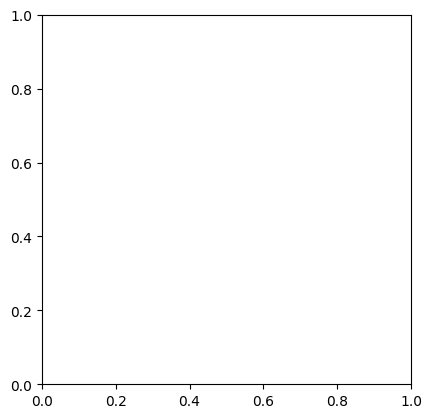

In [11]:
test_image = cv2.imread("/content/Normal.jpeg")
plt.imshow(test_image)

In [ ]:
test_image2 = cv2.imread("/content/Pneumonia.jpeg")
plt.imshow(test_image2)

In [ ]:
test_image = cv2.resize(test_image, (150,150))
test_input = test_image.reshape((1,150,150,3))

test_image2 = cv2.resize(test_image2, (150,150))
test_input2 = test_image2.reshape((1,150,150,3))

In [ ]:
VGG16Model.predict(test_input)

In [ ]:
VGG16Model.predict(test_input2)